# Modelo matemático de BFSK con índice de modulación

La modulación **FSK** (*Frequency Shift Keying*) representa la información digital mediante cambios de frecuencia.  
En el caso binario, llamado **BFSK**, se usan dos frecuencias:

$$
1 \rightarrow f_1
$$

$$
0 \rightarrow f_0
$$

donde normalmente:

$$
f_0 = f_c - \Delta f
$$

$$
f_1 = f_c + \Delta f
$$

Por tanto, la separación entre los dos tonos es:

$$
f_1-f_0 = 2\Delta f
$$

donde:

- $f_c$ es la frecuencia central.
- $\Delta f$ es la desviación de frecuencia.
- $f_0$ es la frecuencia asociada al bit $0$.
- $f_1$ es la frecuencia asociada al bit $1$.

Para introducir el índice de modulación de FSK se define:

$$
h = 2\Delta f T_s
$$

Como:

$$
f_1-f_0 = 2\Delta f
$$

entonces:

$$
h = (f_1-f_0)T_s
$$

Por tanto, la separación entre tonos puede escribirse como:

$$
f_1-f_0 = \frac{h}{T_s}
$$

También se puede despejar la desviación de frecuencia:

$$
\Delta f = \frac{h}{2T_s}
$$

Por tanto:

$$
f_0 = f_c - \frac{h}{2T_s}
$$

$$
f_1 = f_c + \frac{h}{2T_s}
$$

Para BFSK, si cada símbolo representa un bit, entonces:

$$
T_s = T_b
$$

donde:

- $T_s$ es el tiempo de símbolo.
- $T_b$ es el tiempo de bit.

Sea una secuencia binaria:

$$
b_k \in \{0,1\}
$$

Durante el intervalo:

$$
kT_s \leq t < (k+1)T_s
$$

la frecuencia transmitida es:

$$
f_k =
\begin{cases}
f_0, & b_k=0 \\[4pt]
f_1, & b_k=1
\end{cases}
$$

El modelo BFSK por intervalos de símbolo se escribe como:

$$
s_k(t) =
A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

Aquí se usa el tiempo local:

$$
\tau = t-kT_s
$$

Por eso también puede escribirse:

$$
s_k(\tau)=A\cos(2\pi f_k \tau+\phi_0)
$$

con:

$$
0 \leq \tau < T_s
$$

Entonces, la señal completa se puede escribir como:

$$
s(t)=
\sum_{k=-\infty}^{\infty}
A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
p(t-kT_s)
$$

donde el pulso rectangular es:

$$
p(t-kT_s)=
\begin{cases}
1, & kT_s \leq t < (k+1)T_s \\[4pt]
0, & \text{en otro caso}
\end{cases}
$$

Sustituyendo las frecuencias en función del índice de modulación:

$$
f_k =
\begin{cases}
f_c-\dfrac{h}{2T_s}, & b_k=0 \\[8pt]
f_c+\dfrac{h}{2T_s}, & b_k=1
\end{cases}
$$

Por tanto:

$$
s_k(t)=
\begin{cases}
A\cos\left[
2\pi\left(f_c-\dfrac{h}{2T_s}\right)(t-kT_s)+\phi_0
\right], & b_k=0 \\[10pt]
A\cos\left[
2\pi\left(f_c+\dfrac{h}{2T_s}\right)(t-kT_s)+\phi_0
\right], & b_k=1
\end{cases}
$$

Este modelo corresponde a la figura, porque en cada intervalo de duración $T_s$ la señal usa una frecuencia distinta:

$$
1 \rightarrow f_1
$$

$$
0 \rightarrow f_0
$$

Si $b_k=1$, la señal oscila más rápido porque usa $f_1$.  
Si $b_k=0$, la señal oscila más lento porque usa $f_0$.

En este modelo puede aparecer discontinuidad en los cambios de símbolo porque la fase se reinicia en cada intervalo. En efecto, al final del símbolo $k$ la señal vale aproximadamente:

$$
s_k((k+1)T_s^-)
=
A\cos(2\pi f_kT_s+\phi_0)
$$

pero al inicio del siguiente símbolo vale:

$$
s_{k+1}((k+1)T_s^+)
=
A\cos(\phi_0)
$$

En general:

$$
A\cos(2\pi f_kT_s+\phi_0)
\neq
A\cos(\phi_0)
$$

Por eso la señal puede tener un salto de amplitud en los cambios de símbolo.

Si se quiere evitar esa discontinuidad, se usa FSK de fase continua. En ese caso el modelo no reinicia la fase, sino que acumula la fase:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_{-\infty}^{t} a(\lambda)d\lambda
\right]
$$

donde:

$$
a(t)\in\{-1,+1\}
$$

En FSK de fase continua no hay salto de amplitud, pero sí hay cambio brusco en la frecuencia instantánea.

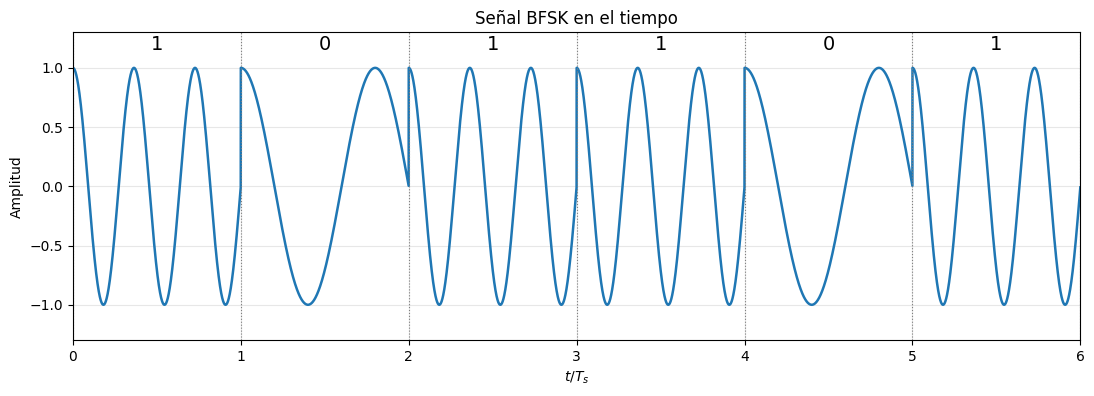

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros BFSK
# ============================================================

A = 1.0                 # Amplitud
Ts = 1.0                # Tiempo de símbolo
fc = 2.0 / Ts           # Frecuencia central

h = 1.5                 # Índice de modulación
df = h / (2 * Ts)       # Desviación de frecuencia

f0 = fc - df            # Frecuencia para bit 0
f1 = fc + df            # Frecuencia para bit 1

bits = np.array([1, 0, 1, 1, 0, 1])
Nsym = len(bits)

fs = 2000
t = np.arange(0, Nsym * Ts, 1 / fs)

s = np.zeros_like(t)

phi0 = 0.0

# ============================================================
# Señal BFSK por intervalos de símbolo
# ============================================================

for k, bit in enumerate(bits):
    t_ini = k * Ts
    t_fin = (k + 1) * Ts

    idx = (t >= t_ini) & (t < t_fin)

    tau = t[idx] - t_ini

    if bit == 1:
        fk = f1
    else:
        fk = f0

    s[idx] = A * np.cos(2 * np.pi * fk * tau + phi0)

# ============================================================
# Gráfica de la señal en el tiempo
# ============================================================

plt.figure(figsize=(13, 4))

plt.plot(t / Ts, s, linewidth=1.8)

for k in range(Nsym + 1):
    plt.axvline(k, color="gray", linestyle=":", linewidth=0.8)

for k, bit in enumerate(bits):
    plt.text(k + 0.5, 1.15, str(bit), ha="center", fontsize=14)

plt.xlabel(r"$t/T_s$")
plt.ylabel("Amplitud")
plt.title("Señal BFSK en el tiempo")
plt.xlim(0, Nsym)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)

plt.show()

# Modelo matemático de CPFSK

La modulación **CPFSK** significa:

$$
\text{Continuous Phase Frequency Shift Keying}
$$

En español:

$$
\text{FSK de fase continua}
$$

Es una versión de FSK en la cual la información digital se transmite cambiando la frecuencia de la portadora, pero imponiendo que la **fase no tenga saltos** en los cambios de símbolo.

En una FSK convencional por tramos, la señal puede escribirse como:

$$
s_k(t)=A\cos\left(2\pi f_k(t-kT_s)+\phi_0\right)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

donde $f_k$ cambia dependiendo del bit transmitido.  
El problema de este modelo es que la fase puede reiniciarse en cada símbolo. Por eso pueden aparecer discontinuidades en la señal.

Para evitar ese problema, en CPFSK se impone que la fase sea continua.

La condición fundamental de CPFSK es:

$$
\theta((k+1)T_s^-)=\theta((k+1)T_s^+)
$$

donde:

- $\theta((k+1)T_s^-)$ es la fase justo antes del cambio de símbolo.
- $\theta((k+1)T_s^+)$ es la fase justo después del cambio de símbolo.
- $T_s$ es el tiempo de símbolo.

Esto significa que la fase no puede saltar cuando cambia el bit.

---

## Señal CPFSK general

La señal pasabanda se define como:

$$
s(t)=A\cos(\theta(t))
$$

donde:

- $A$ es la amplitud de la señal.
- $\theta(t)$ es la fase instantánea.

La frecuencia instantánea se relaciona con la fase mediante:

$$
f_i(t)=\frac{1}{2\pi}\frac{d\theta(t)}{dt}
$$

Por tanto, si conocemos la frecuencia instantánea, podemos obtener la fase integrando:

$$
\theta(t)=2\pi\int_0^t f_i(\lambda)d\lambda+\theta(0)
$$

donde:

- $f_i(t)$ es la frecuencia instantánea.
- $\theta(0)$ es la fase inicial.

En CPFSK, la frecuencia instantánea cambia según la señal digital transmitida, pero la fase se obtiene por acumulación. Por eso la fase no se reinicia.

---

## Señal digital polar

Para BFSK, la información binaria puede representarse mediante una señal polar:

$$
a_k \in \{-1,+1\}
$$

Se puede asignar:

$$
b_k=0 \rightarrow a_k=-1
$$

$$
b_k=1 \rightarrow a_k=+1
$$

donde:

- $b_k$ es el bit transmitido.
- $a_k$ es el símbolo polar asociado.

La señal digital polar en el tiempo se escribe como:

$$
a(t)=\sum_{k=-\infty}^{\infty} a_k p(t-kT_s)
$$

donde $p(t)$ es un pulso rectangular de duración $T_s$:

$$
p(t)=
\begin{cases}
1, & 0\leq t<T_s \\[4pt]
0, & \text{en otro caso}
\end{cases}
$$

Entonces, durante cada símbolo:

$$
a(t)=a_k
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

---

## Frecuencia instantánea en CPFSK

En CPFSK binaria, la frecuencia instantánea se define como:

$$
f_i(t)=f_c+\Delta f\,a(t)
$$

donde:

- $f_c$ es la frecuencia central.
- $\Delta f$ es la desviación de frecuencia.
- $a(t)$ es la señal digital polar.

Como $a(t)$ solo puede tomar los valores $-1$ y $+1$, entonces:

Si:

$$
a(t)=-1
$$

la frecuencia instantánea es:

$$
f_i(t)=f_c-\Delta f
$$

y se transmite la frecuencia:

$$
f_0=f_c-\Delta f
$$

Si:

$$
a(t)=+1
$$

la frecuencia instantánea es:

$$
f_i(t)=f_c+\Delta f
$$

y se transmite la frecuencia:

$$
f_1=f_c+\Delta f
$$

Por tanto:

$$
0 \rightarrow f_0=f_c-\Delta f
$$

$$
1 \rightarrow f_1=f_c+\Delta f
$$

La separación entre los dos tonos es:

$$
f_1-f_0=2\Delta f
$$

---

## Índice de modulación en CPFSK

El índice de modulación de FSK se define como:

$$
h=2\Delta f T_s
$$

Como:

$$
f_1-f_0=2\Delta f
$$

entonces también se puede escribir:

$$
h=(f_1-f_0)T_s
$$

De esta expresión se obtiene:

$$
f_1-f_0=\frac{h}{T_s}
$$

La desviación de frecuencia queda:

$$
\Delta f=\frac{h}{2T_s}
$$

Por tanto, las frecuencias de CPFSK se pueden escribir en función del índice de modulación:

$$
f_0=f_c-\frac{h}{2T_s}
$$

$$
f_1=f_c+\frac{h}{2T_s}
$$

El índice de modulación $h$ controla la separación entre los tonos:

- Si $h$ aumenta, $f_0$ y $f_1$ quedan más separados.
- Si $h$ disminuye, $f_0$ y $f_1$ quedan más cercanos.

---

## Fase instantánea de CPFSK

La señal CPFSK se construye acumulando la frecuencia instantánea.

Partiendo de:

$$
f_i(t)=f_c+\Delta f\,a(t)
$$

y usando:

$$
\theta(t)=2\pi\int_0^t f_i(\lambda)d\lambda+\theta(0)
$$

se obtiene:

$$
\theta(t)
=
2\pi\int_0^t
\left[
f_c+\Delta f\,a(\lambda)
\right]
d\lambda
+\theta(0)
$$

Separando los términos:

$$
\theta(t)
=
2\pi f_c t
+
2\pi\Delta f
\int_0^t a(\lambda)d\lambda
+\theta(0)
$$

Por tanto, la señal CPFSK queda:

$$
s(t)=A\cos\left[
2\pi f_c t
+
2\pi\Delta f
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Usando:

$$
\Delta f=\frac{h}{2T_s}
$$

se obtiene:

$$
s(t)=A\cos\left[
2\pi f_c t
+
2\pi\left(\frac{h}{2T_s}\right)
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Simplificando:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

Esta es la expresión general de una señal **CPFSK binaria**.

---

## Modelo por intervalos de símbolo

Durante el intervalo:

$$
kT_s \leq t < (k+1)T_s
$$

la señal polar vale:

$$
a(t)=a_k
$$

Por tanto, la frecuencia instantánea durante ese símbolo es constante:

$$
f_k=f_c+\Delta f\,a_k
$$

o usando el índice de modulación:

$$
f_k=f_c+a_k\frac{h}{2T_s}
$$

Si $a_k=-1$:

$$
f_k=f_c-\frac{h}{2T_s}=f_0
$$

Si $a_k=+1$:

$$
f_k=f_c+\frac{h}{2T_s}=f_1
$$

La fase dentro del símbolo $k$ se puede escribir como:

$$
\theta_k(t)
=
\theta(kT_s)
+
2\pi f_k(t-kT_s)
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

Entonces, la señal CPFSK durante el símbolo $k$ es:

$$
s_k(t)
=
A\cos\left[
\theta(kT_s)
+
2\pi f_k(t-kT_s)
\right]
$$

La diferencia con FSK convencional es que $\theta(kT_s)$ no se reinicia.  
Ese valor es la fase acumulada hasta el inicio del símbolo $k$.

---

## Recursión de fase

Para garantizar continuidad de fase, la fase inicial de cada símbolo debe ser igual a la fase final del símbolo anterior.

Al final del símbolo $k$, es decir en:

$$
t=(k+1)T_s
$$

la fase vale:

$$
\theta((k+1)T_s)
=
\theta(kT_s)
+
2\pi f_k T_s
$$

Por tanto, la fase se actualiza recursivamente como:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_k T_s
$$

donde:

$$
\theta_k=\theta(kT_s)
$$

Sustituyendo:

$$
f_k=f_c+a_k\frac{h}{2T_s}
$$

se obtiene:

$$
\theta_{k+1}
=
\theta_k
+
2\pi
\left(
f_c+a_k\frac{h}{2T_s}
\right)
T_s
$$

Distribuyendo:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_c T_s
+
\pi h a_k
$$

Esta ecuación muestra cómo evoluciona la fase símbolo a símbolo.

La fase no se reinicia, sino que se acumula.

---

## Condición de continuidad de fase

En FSK por tramos con fase reiniciada se puede tener:

$$
s_k((k+1)T_s^-)
\neq
s_{k+1}((k+1)T_s^+)
$$

Eso ocurre porque cada símbolo puede iniciar con la misma fase $\phi_0$, sin tener en cuenta cómo terminó el símbolo anterior.

En CPFSK se impone:

$$
\theta_{k+1}^{\text{inicio}}
=
\theta_k^{\text{final}}
$$

Por eso:

$$
s_k((k+1)T_s^-)
=
s_{k+1}((k+1)T_s^+)
$$

Esto elimina los saltos de amplitud en la señal.

La frecuencia sí puede cambiar bruscamente de un símbolo al siguiente:

$$
f_0 \leftrightarrow f_1
$$

pero la fase no cambia de forma brusca.

---

## Relación entre CPFSK y MSK

Un caso muy importante de CPFSK es **MSK**:

$$
\text{Minimum Shift Keying}
$$

MSK ocurre cuando:

$$
h=\frac{1}{2}
$$

Como:

$$
f_1-f_0=\frac{h}{T_s}
$$

si:

$$
h=\frac{1}{2}
$$

entonces:

$$
f_1-f_0=\frac{1}{2T_s}
$$

Este valor corresponde a la mínima separación entre tonos que permite una forma eficiente de modulación de fase continua.

Por eso MSK puede interpretarse como una CPFSK con índice de modulación:

$$
h=\frac{1}{2}
$$

---

## Valores de $h$ en CPFSK

Para que una señal sea CPFSK no se exige un único valor de $h$.  
La propiedad de fase continua se obtiene imponiendo que la fase se acumule y no se reinicie.

En teoría:

$$
h>0
$$

puede usarse en CPFSK.

Sin embargo, en sistemas prácticos se suelen usar valores racionales:

$$
h=\frac{m}{p}
$$

donde $m$ y $p$ son enteros.

Ejemplos comunes son:

$$
h=\frac{1}{2}
$$

$$
h=\frac{1}{3}
$$

$$
h=\frac{2}{3}
$$

$$
h=1
$$

El caso más importante es:

$$
h=\frac{1}{2}
$$

porque corresponde a MSK.

---

## Forma final del modelo CPFSK binario

Sea:

$$
a_k\in\{-1,+1\}
$$

con:

$$
0 \rightarrow -1
$$

$$
1 \rightarrow +1
$$

La frecuencia instantánea es:

$$
f_i(t)=f_c+\frac{h}{2T_s}a(t)
$$

donde:

$$
a(t)=\sum_{k=-\infty}^{\infty}a_kp(t-kT_s)
$$

La fase instantánea es:

$$
\theta(t)
=
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
$$

La señal CPFSK es:

$$
s(t)=A\cos\left[
2\pi f_c t
+
\frac{\pi h}{T_s}
\int_0^t a(\lambda)d\lambda
+\theta(0)
\right]
$$

En forma recursiva por símbolo:

$$
s_k(t)=A\cos\left[
\theta_k+
2\pi
\left(
f_c+a_k\frac{h}{2T_s}
\right)
(t-kT_s)
\right]
$$

para:

$$
kT_s \leq t < (k+1)T_s
$$

con actualización de fase:

$$
\theta_{k+1}
=
\theta_k
+
2\pi f_c T_s
+
\pi h a_k
$$

Esta recursión es la que garantiza que la fase sea continua entre símbolos.

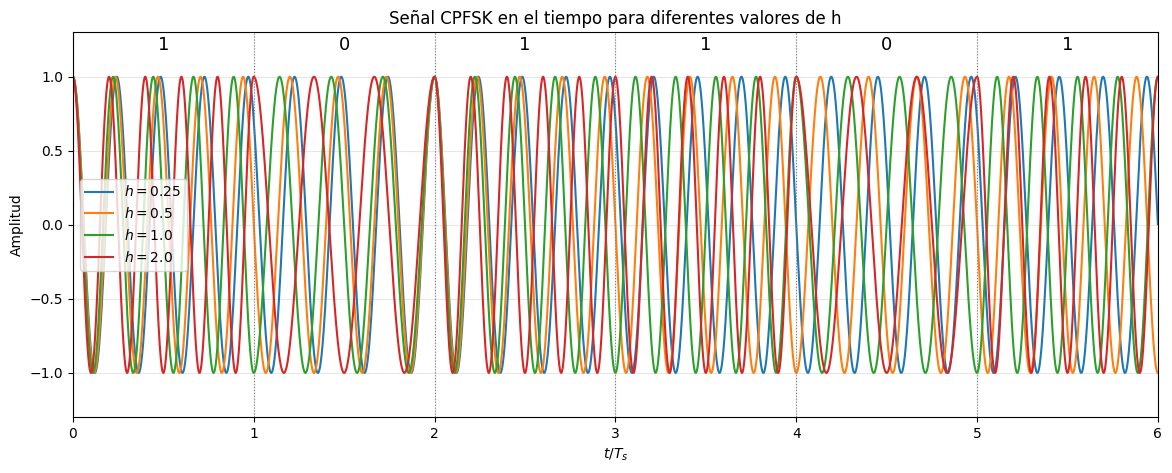

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Parámetros de la señal CPFSK
# ============================================================

A = 1.0
Ts = 1.0
fc = 4.0

bits = np.array([1, 0, 1, 1, 0, 1])
Nsym = len(bits)

fs = 5000
t = np.arange(0, Nsym * Ts, 1 / fs)

h_values = [0.25, 0.5, 1.0, 2.0]

# ============================================================
# Señal digital polar
# bit 0 -> -1
# bit 1 -> +1
# ============================================================

a = np.zeros_like(t)

for k, bit in enumerate(bits):
    idx = (t >= k * Ts) & (t < (k + 1) * Ts)

    if bit == 1:
        a[idx] = 1
    else:
        a[idx] = -1

# Integral de la señal polar
integral_a = np.concatenate(([0], np.cumsum(a[:-1]) / fs))

# ============================================================
# Gráfica de CPFSK para diferentes valores de h
# ============================================================

plt.figure(figsize=(14, 5))

for h in h_values:
    theta = 2 * np.pi * fc * t + (np.pi * h / Ts) * integral_a
    s = A * np.cos(theta)

    plt.plot(t / Ts, s, linewidth=1.5, label=fr"$h={h}$")

# Límites de símbolo
for k in range(Nsym + 1):
    plt.axvline(k, color="gray", linestyle=":", linewidth=0.8)

# Bits sobre la gráfica
for k, bit in enumerate(bits):
    plt.text(k + 0.5, 1.18, str(bit), ha="center", fontsize=13)

plt.xlabel(r"$t/T_s$")
plt.ylabel("Amplitud")
plt.title("Señal CPFSK en el tiempo para diferentes valores de h")
plt.xlim(0, Nsym)
plt.ylim(-1.3, 1.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()